# Configuración 1: 1D-CNN (a) + PINN (b)

**Anexo de código del TFM.** Pronóstico de crecimiento de grietas por fatiga (PHM Data Challenge 2019).
Carlos J. Bravo I.

Ésta es la **configuración base** del estudio de ablación: un codificador convolucional
unidimensional que estima la longitud de grieta a partir de las ondas de Lamb (componente **a**),
acoplado a un módulo físicamente informado que identifica el coeficiente de la ley de
Paris-Erdogan y extrapola con él más allá del corte de señal (componente **b**).

Las configuraciones 2, 3 y 4 se comparan **contra ésta**, de modo que todo lo que aquí se fija se
hereda sin cambios: el preprocesado, el protocolo, la pérdida y los hiperparámetros físicos.

## Contenido

| Apartado | Contenido |
|---|---|
| 1 | Los datos de entrada y su preparación |
| 2 | La ley física y la identificación de sus constantes |
| 3 | El modelo |
| 4 | Selección de los hiperparámetros |
| 5 | Entrenamiento |
| 6 | Resultados sobre T7 y T8 |
| 7 | Atribución del error |
| 8 | El coeficiente que T8 habría necesitado |
| 9 | Conclusiones |

In [ ]:
import json
import sys
import time
import warnings
from dataclasses import asdict
from pathlib import Path

RAIZ = next(d for d in (Path.cwd(), *Path.cwd().parents)
            if (d / "config1_cnn_pinn" / "model.py").is_file())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

warnings.filterwarnings("ignore")
torch.set_num_threads(4)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

from config1_cnn_pinn import cota_extrapolacion, sensibilidad
from config1_cnn_pinn import signals as S
from config1_cnn_pinn.data import build_specimen_batches, load_labels
from config1_cnn_pinn.evaluate import (ABLATION, BASE, REFERENCES, build_submission,
                                       coefficient_diagnostic, n_observed_nonzero,
                                       summarise, tabla_comparativa)
from config1_cnn_pinn.hyperparameter_sources import SOURCES, comparar_procedencias
from config1_cnn_pinn.model import CnnPinn
from config1_cnn_pinn.physics import equivalent_stress_range, fit_log_c, pooled_log_c
from config1_cnn_pinn.robustez_literatura import robustez_constantes
from config1_cnn_pinn.select import GRID, search
from config1_cnn_pinn.select_prognosis import buscar_exponente
from config1_cnn_pinn.select_weighting import buscar_peso
from config1_cnn_pinn.t8_study import trajectory, verificar_coeficiente
from config1_cnn_pinn.train import (Config, LOSO_FOLDS, RESULTS, TRAIN_POOL,
                                    train_ensemble)
from physics_calibration.data import CALIBRATION_SPECIMENS, load_curve
from physics_calibration.objectives import phm_penalty

RESULTS.mkdir(exist_ok=True)
INICIO = time.perf_counter()


def marca_de_agua(fig):
    fig.text(0.99, 0.01, "Carlos J. Bravo (2026)", color="0.45", alpha=0.38,
             fontweight="bold", ha="right", va="bottom", fontsize=8)


def cerrar(fig, nombre=None):
    marca_de_agua(fig)
    fig.tight_layout()
    plt.show()

from pesos_entrenados import cargar_o_entrenar, inventario

# Los pesos se guardan en models/ y se reutilizan: entrenar de cero sólo cambia
# el tiempo, no el resultado, porque la siembra está fijada. Poner a True para
# rehacer el entrenamiento e ignorar lo guardado.
ENTRENAR_DE_NUEVO = False


## 1. Los datos de entrada y su preparación

### 1.1 De qué se dispone

El certamen publica ocho probetas remachadas de aluminio 2024-T3. Seis de ellas, T1 a T6, vienen con
la longitud de grieta medida ópticamente a lo largo de toda su vida, y son las que se pueden usar
para entrenar. Las dos restantes, T7 y T8, son las que hay que predecir.

Cada probeta lleva un par de transductores piezoeléctricos: uno emite un pulso y el otro recibe la
onda de Lamb que ha atravesado la zona remachada. A medida que la grieta crece, esa onda llega con
un retardo submicrosegundo y con la amplitud alterada. Esa diferencia es toda la información
disponible.

La restricción que gobierna todas las decisiones de este apartado es el tamaño: en toda la
publicación existen **menos de noventa formas de onda etiquetadas**.

In [2]:
etiquetas = load_labels()

filas = []
for nombre in S.TRAINING_SPECIMENS + S.VALIDATION_SPECIMENS:
    curva = load_curve(nombre)
    ciclos_senal = S.signal_cycles(name=nombre)
    con_etiqueta = [c for c in ciclos_senal if c in set(curva.cycles)]
    ondas = sum(len(S.available_repetitions(S.DEFAULT_ROOT, nombre, c))
                for c in con_etiqueta if (nombre, c) not in S.EXCLUDED_RECORDS)
    filas.append({
        "espécimen": nombre,
        "papel": "entrenamiento" if nombre in S.TRAINING_SPECIMENS else "validación",
        "medidas de grieta": len(curva.cycles),
        "ciclos con señal": len(ciclos_senal),
        "ondas etiquetadas": ondas,
        "grieta final (mm)": round(float(curva.final_crack_mm), 2),
        "último ciclo con señal": max(ciclos_senal),
        "grieta en ese ciclo (mm)": round(float(curva.crack_mm[curva.cycles <= max(ciclos_senal)][-1]), 2),
    })

inventario = pd.DataFrame(filas)
display(inventario)
print(f"Ondas etiquetadas en total: {inventario['ondas etiquetadas'].sum()}")

,espécimen,papel,medidas de grieta,ciclos con señal,ondas etiquetadas,grieta final (mm),último ciclo con señal,grieta en ese ciclo (mm)
0,T1,entrenamiento,6,7,12,7.46,70766,7.46
1,T2,entrenamiento,2,3,4,4.95,72000,4.95
2,T3,entrenamiento,7,10,14,6.93,66510,6.93
3,T4,entrenamiento,7,8,14,7.24,75045,7.24
4,T5,entrenamiento,2,3,3,3.64,56000,3.64
5,T6,entrenamiento,5,6,10,5.08,73211,5.08
6,T7,validación,6,4,4,7.22,47022,3.14
7,T8,validación,7,5,4,5.52,76931,2.50


Ondas etiquetadas en total: 65


### 1.2 Alineación, ventaneo y canal diferencial

El retardo que produce la grieta es de fracciones de microsegundo. El instante en que el equipo de
adquisición dispara varía, entre registro y registro, **en ese mismo orden de magnitud**. Comparar
dos ondas sin corregir ese desfase mide ruido de disparo, no daño.

La preparación consta de cuatro pasos, todos ellos dictados por el tamaño del conjunto:

**Alineación de fase.** El desfase se mide sobre la traza del actuador, que es idéntica en todos los
registros y por tanto sólo contiene el desfase de disparo, y se aplica a la traza del sensor.

**Ventaneo del paquete S0**, entre 90 y 145 microsegundos. Descarta cerca del 85 % del registro, que
es silencio anterior a la llegada de la onda y reverberación posterior.

**Canal diferencial.** A la red se le presentan dos canales: la onda estandarizada y su diferencia
contra el registro de la misma probeta cuando todavía estaba sana. Lo que informa del daño es el
cambio respecto a uno mismo, no la forma absoluta.

**Normalización por probeta.** Cada probeta está instrumentada sobre un par emisor-receptor
distinto, con distinta distancia de propagación y distinto pegado del transductor, de modo que la
amplitud absoluta de la firma de daño no es comparable entre probetas. La escala se lee en un
estado de daño por el que pasan todas ellas, la primera medida que alcanza los 2 mm de grieta, y no
en el máximo de cada una: los máximos de T7 y T8 salen sistemáticamente más pequeños porque sus
señales se acaban antes, y dividir por ellos inflaría las dos probetas que se juzgan.

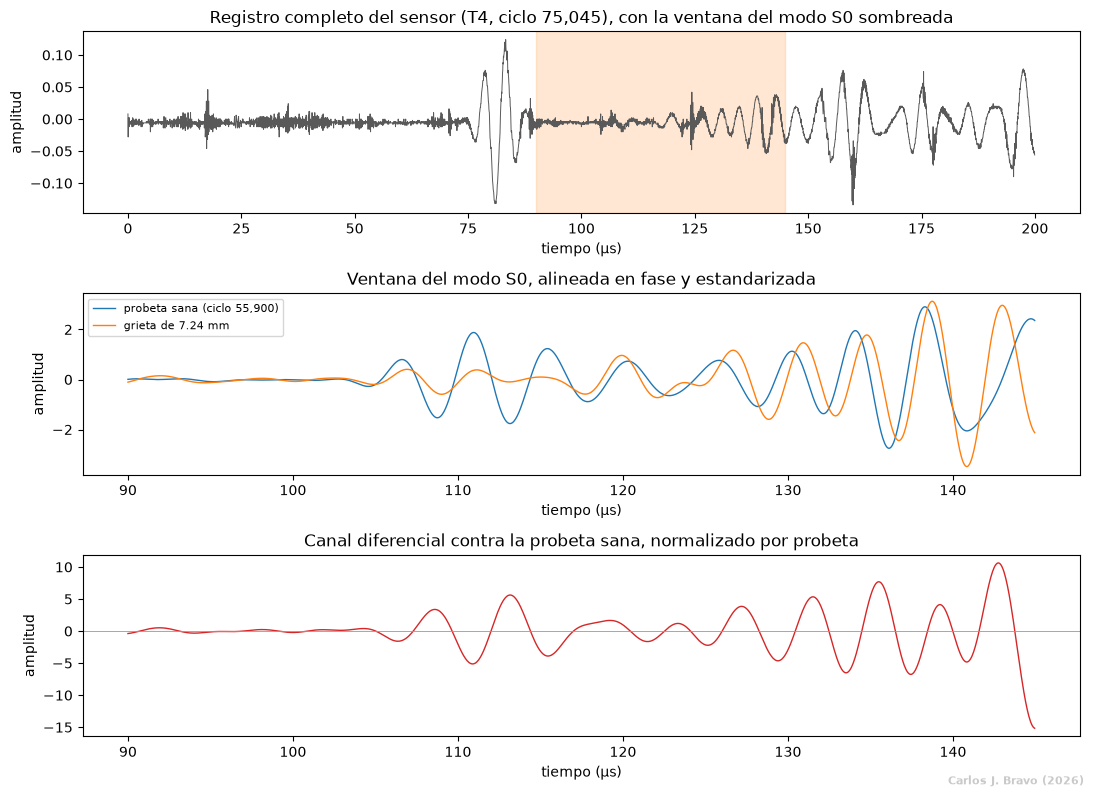

In [3]:
ejemplo = "T4"
ciclos_ej = [c for c in S.signal_cycles(name=ejemplo)]
ciclo_sano, ciclo_danado = ciclos_ej[0], ciclos_ej[-1]
curva_ej = load_curve(ejemplo)
grieta_danada = float(curva_ej.crack_mm[curva_ej.cycles <= ciclo_danado][-1])

t_us = np.arange(S.N_SAMPLES) / S.SAMPLING_HZ * 1e6
cruda = S.raw_waveform(ejemplo, ciclo_danado)
sana = S.reference_waveform(ejemplo)
par = S.encode(ejemplo, ciclo_danado)

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=False)

axes[0].plot(t_us, cruda, lw=0.7, color="0.35")
axes[0].axvspan(S.WINDOW_S[0] * 1e6, S.WINDOW_S[1] * 1e6, color="tab:orange", alpha=0.18)
axes[0].set_title(f"Registro completo del sensor ({ejemplo}, ciclo {ciclo_danado:,}), "
                  f"con la ventana del modo S0 sombreada")
axes[0].set_xlabel("tiempo (µs)")
axes[0].set_ylabel("amplitud")

t_win = t_us[S.WINDOW_SLICE]
axes[1].plot(t_win, S.zscore(sana), lw=1.0, label=f"probeta sana (ciclo {ciclo_sano:,})")
axes[1].plot(t_win, par[0], lw=1.0, label=f"grieta de {grieta_danada:.2f} mm")
axes[1].set_title("Ventana del modo S0, alineada en fase y estandarizada")
axes[1].set_xlabel("tiempo (µs)")
axes[1].set_ylabel("amplitud")
axes[1].legend(fontsize=8)

axes[2].plot(t_win, par[1], lw=1.0, color="tab:red")
axes[2].axhline(0, lw=0.6, color="0.6")
axes[2].set_title("Canal diferencial contra la probeta sana, normalizado por probeta")
axes[2].set_xlabel("tiempo (µs)")
axes[2].set_ylabel("amplitud")

cerrar(fig)

### 1.3 Entrada del modelo

Cada probeta se agrupa en un lote propio. La red no recibe ondas sueltas, sino la secuencia completa
de una probeta, porque el coeficiente de la ley de crecimiento es una propiedad de la probeta entera
y el residuo físico se evalúa entre ciclos consecutivos de la misma.

Junto a las dos trazas, cada onda lleva trece descriptores escalares clásicos (energía del canal
diferencial, retardo de fase, correlación con la referencia sana y otros), y el contexto secuencial:
la grieta del ciclo anterior y el salto de ciclos hasta el actual.

In [4]:
cfg_datos = Config(**ABLATION["Configuración 1 (1D-CNN + PINN)"])
lotes = build_specimen_batches(etiquetas, cfg_datos.m_exponent)

filas = []
for nombre, lote in lotes.items():
    filas.append({
        "espécimen": nombre,
        "ondas": int(lote.x.shape[0]),
        "muestras por onda": int(lote.x.shape[2]),
        "canales": int(lote.x.shape[1]),
        "descriptores": int(lote.features.shape[1]),
        "pares consecutivos": int(len(lote.pair_from)),
        "grieta final (mm)": round(float(lote.norm_mm), 2),
        "Δσ equivalente (MPa)": round(float(lote.d_sigma_eq), 2),
    })
display(pd.DataFrame(filas))
print("Descriptores escalares:", ", ".join(S.FEATURE_NAMES))

,espécimen,ondas,muestras por onda,canales,descriptores,pares consecutivos,grieta final (mm),Δσ equivalente (MPa)
0,T1,14,1100,2,13,5,7.46,95.44
1,T2,6,1100,2,13,1,4.95,95.44
2,T3,18,1100,2,13,6,6.93,95.44
3,T4,16,1100,2,13,6,7.24,95.44
4,T5,5,1100,2,13,1,3.64,95.44
5,T6,12,1100,2,13,4,5.08,95.44
6,T7,8,1100,2,13,1,7.22,95.44
7,T8,8,1100,2,13,1,5.52,90.48


Descriptores escalares: rms_diferencial, max_diferencial, correlacion, rms_ventana_0, rms_ventana_1, rms_ventana_2, rms_ventana_3, rms_ventana_4, rms_ventana_5, rms_ventana_6, rms_ventana_7, centroide_temporal, retardo_fase_us


## 2. La ley física y la identificación de sus constantes

### 2.1 Estimación y prognosis

El certamen plantea dos tareas de naturaleza distinta, y los resultados sólo son legibles si se
informan por separado:

| Tarea | Información disponible | Quién la resuelve aquí |
|---|---|---|
| **Estimación** | hay señal ultrasónica: se lee y se convierte en milímetros | el codificador 1D-CNN, componente (a) |
| **Prognosis** | ya no hay señal; sólo la última grieta estimada y el perfil de carga futuro | la ley de Paris con el coeficiente del PINN, componente (b) |

Para T7 la señal se acaba en el ciclo 47 022 y para T8 en el 76 931, bastante antes del final de su
vida. Todo lo posterior sale de propagar hacia delante desde la última grieta estimada, de modo que
la mitad de prognosis depende de dos cantidades: dónde queda esa última estimación, el **ancla**, y
con qué velocidad se propaga, el **coeficiente**.

### 2.2 La ley de Paris y la elección del exponente

La ley de Paris-Erdogan relaciona el avance de la grieta por ciclo con el rango del factor de
intensidad de tensiones:

$$\frac{da}{dN} = C\,(\Delta K)^m, \qquad \Delta K = \Delta\sigma\sqrt{\pi a}$$

Con el factor geométrico igual a uno, esa ecuación se integra en forma cerrada. La forma de la
solución depende del exponente, y la diferencia entre las dos formas posibles no es de precisión
sino estructural. Llamando *p* = 1 − *m*/2, la solución es

$$a(N) = \left[a_0^{\,p} + p\,k\,N\right]^{1/p}$$

Para *m* > 2 el exponente *p* es negativo, el corchete **cruza cero en tiempo finito** y la grieta
predicha diverge a infinito. Para *m* = 2 exactamente, la solución degenera en una exponencial,
*a*(*N*) = *a*₀·exp(*kN*), que crece sin cota pero nunca en tiempo finito, y que es monótona
creciente por construcción, con lo que el factor de monotonía del certamen se cumple sin imponerlo.

Con un coeficiente identificado a partir de cuatro probetas, un error de unas pocas décimas de
década es esperable. Bajo la primera forma ese error produce una grieta infinita; bajo la segunda,
una grieta algo mayor de la real.

### 2.3 El coeficiente se re-identifica al exponente en uso

*C* y *m* no son independientes: se desplazan juntos a lo largo de la cresta del ajuste, de modo
que un coeficiente citado a un exponente distinto del suyo es incorrecto, y la diferencia es grande,
como muestra la tabla siguiente. El coeficiente no se lee, por tanto, de ninguna constante guardada:
se vuelve a identificar en cada ejecución, al exponente en uso, sobre las cuatro probetas de
entrenamiento con curva completa. **No entra ningún dato de T7 ni de T8.**

In [5]:
filas = []
for m in (2.00, 2.0632, 2.25, 2.50, 3.00):
    log_c = pooled_log_c(m)
    filas.append({"m": m, "log10 C poblacional": round(log_c, 4), "C": f"{10 ** log_c:.3e}"})
display(pd.DataFrame(filas))

filas = []
for nombre in CALIBRATION_SPECIMENS:
    curva = load_curve(nombre)
    d_sigma = equivalent_stress_range(curva.load_block, 2.00)
    filas.append({
        "espécimen": nombre,
        "medidas": len(curva.cycles),
        "Δσ equivalente (MPa)": round(d_sigma, 2),
        "log10 C a m = 2,00": round(fit_log_c(curva.cycles, curva.crack_mm, 2.00, d_sigma), 4),
    })
por_especimen = pd.DataFrame(filas)
display(por_especimen)
print(f"dispersión entre probetas: {por_especimen['log10 C a m = 2,00'].std():.4f} dex")

,m,log10 C poblacional,C
0,2.0000,-8.4264,3.746e-09
1,2.0632,-8.4872,3.257e-09
2,2.2500,-8.6674,2.151e-09
3,2.5000,-8.9076,1.237e-09
4,3.0000,-9.3876,4.097e-10


,espécimen,medidas,Δσ equivalente (MPa),"log10 C a m = 2,00"
0,T1,6,95.44,-8.4710
1,T3,7,95.44,-8.4325
2,T4,7,95.44,-8.4920
3,T6,5,95.44,-8.3100


dispersión entre probetas: 0.0814 dex


La dispersión entre probetas es pequeña, alrededor de una décima de década. Ese hecho justifica la
forma de la cabeza física del apartado siguiente: el exponente se comparte entre todas las probetas
y el coeficiente es lo único que varía de una a otra, dentro de un margen estrecho.

Fijar el factor geométrico en uno tiene una consecuencia sobre la magnitud del coeficiente. El valor
que resulta queda unas dos décadas por encima de cualquiera publicado para este aluminio en probeta
de laboratorio, porque ha de absorber además la complianza del agujero avellanado y del remache. No
es un coeficiente de material, sino de esta junta. El apartado 7 mide el efecto de sustituirlo por
uno publicado.

## 3. El modelo

La capacidad la fijan los datos, no la ambición: con menos de noventa ondas etiquetadas, el
codificador es deliberadamente pequeño, con zancada en lugar de agrupamiento, y regularizado con
normalización por lotes, apagado aleatorio y decaimiento de pesos. Una red convolucional de escala
moderna memorizaría este conjunto en unas pocas épocas y no generalizaría a nada.

**El tronco convolucional** son cuatro bloques en cascada, cada uno con una convolución
unidimensional sin sesgo, normalización por lotes y activación GELU. Los núcleos se acortan y los
canales se ensanchan a medida que la traza se comprime, de 15 a 5 muestras y de 8 a 32 canales, de
modo que las primeras capas ven tramos largos de onda y las últimas, detalles locales sobre una
representación ya resumida. La reducción se consigue con zancada, no con agrupamiento. Al final, la
traza comprimida se resume en un vector por dos vías complementarias, su promedio temporal, que
sigue la atenuación global, y su máximo, que sigue el eco dispersado más fuerte, y una proyección
lineal las combina en el latente.

Sobre ese latente compartido se apoyan tres capas de salida.

**Cabeza de grieta.** Recibe el latente, los trece descriptores escalares y el contexto secuencial.
Combinar ambas representaciones, la aprendida por el codificador y la diseñada a mano, es lo que
permite trabajar con menos de noventa ondas etiquetadas: por separado, ninguna de las dos sostiene
la estimación. Su salida es incremental, la grieta anterior más un incremento no negativo,
de modo que es monótona creciente por construcción. Una segunda capa cubre el primer ciclo, donde no
existe grieta anterior de la que partir.

**Cabeza de coeficiente.** Emite un coeficiente **por probeta**, no por onda, porque es una
propiedad de la probeta y no de cada medida. Lee el latente promediado sobre todas las ondas de la
probeta y está acotada por construcción:

$$\log_{10}C = \text{valor poblacional} + \text{rango}\cdot\tanh(u)$$

El reparto entre red y pérdida merece una precisión, porque el apellido *informado por la física* puede
inducir a error. Esta cabeza es una capa de la red como las demás, con sus pesos y su gradiente, y
aparece en el resumen de abajo. Lo que no es una capa es el **residuo de la ley de crecimiento**:
ése vive en la función de pérdida del apartado 4, y es el que obliga a que el coeficiente emitido
reproduzca el crecimiento observado entre ciclos consecutivos. Sin ese término la cabeza seguiría
existiendo, pero nada la ataría a la mecánica de la fractura.

La descripción que sigue es la que produce la propia biblioteca al imprimir el modelo.

In [6]:
modelo_demo = CnnPinn(log_c_prior=cfg_datos.log_c_prior, log_c_range=cfg_datos.log_c_range,
                      channels=cfg_datos.channels, latent=cfg_datos.latent,
                      dropout=cfg_datos.dropout,
                      n_features=lotes["T1"].features.shape[1])
lote_demo = lotes["T1"]

print(modelo_demo)

CnnPinn(
  (encoder): CrackEncoder(
    (blocks): Sequential(
      (0): ConvBlock(
        (conv): Conv1d(2, 8, kernel_size=(15,), stride=(4,), padding=(7,), bias=False)
        (norm): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): ConvBlock(
        (conv): Conv1d(8, 16, kernel_size=(9,), stride=(4,), padding=(4,), bias=False)
        (norm): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (2): ConvBlock(
        (conv): Conv1d(16, 24, kernel_size=(7,), stride=(4,), padding=(3,), bias=False)
        (norm): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (3): ConvBlock(
        (conv): Conv1d(24, 32, kernel_size=(5,), stride=(2,), padding=(2,), bias=False)
        (norm): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
    )
    (project): Sequential(
      (0

Esa descripción es la que declara la propia biblioteca: tipos de capa, canales de entrada y de
salida, tamaño de núcleo, zancada y relleno. No incluye, en cambio, ni la forma que toma la señal
al atravesar cada capa ni el reparto de parámetros, que es lo que permite ver dónde está realmente
la capacidad del modelo. La tabla siguiente añade esas dos columnas, midiendo las formas en una
pasada real sobre las ondas de T1 en lugar de deducirlas sobre el papel.

In [7]:
def forma(t):
    return "×".join(str(d) for d in tuple(t.shape)[1:]) if torch.is_tensor(t) else ""


registro, ganchos = [], []


def gancho(nombre):
    def registrar(modulo, entrada, salida):
        registro.append({
            "capa": nombre,
            "tipo": type(modulo).__name__,
            "salida por onda": forma(salida),
            "parámetros": sum(q.numel() for q in modulo.parameters(recurse=False)),
        })
    return registrar


for nombre, modulo in modelo_demo.named_modules():
    if nombre and not list(modulo.children()):
        ganchos.append(modulo.register_forward_hook(gancho(nombre)))

modelo_demo.eval()
with torch.no_grad():
    z = modelo_demo.encoder(lote_demo.x)
    grieta = modelo_demo.crack_mm(z, lote_demo.features, lote_demo.a_prev,
                                  lote_demo.log_dn, lote_demo.dn)
    log_c = modelo_demo.log_c(z, torch.zeros(len(z), dtype=torch.long), 1)

for h in ganchos:
    h.remove()

display(pd.DataFrame(registro))

print(f"entrada por onda        {forma(lote_demo.x)}  (canal estandarizado y canal diferencial)")
print(f"latente compartido      {forma(z)}")
print(f"cabeza de grieta        un valor en mm por onda, {tuple(grieta.shape)[0]} ondas en T1")
print(f"cabeza de coeficiente   un log10 C por espécimen")
print(f"parámetros entrenables  {modelo_demo.n_parameters():,}")
print(f"sin entrenar, el coeficiente arranca en el valor poblacional: {float(log_c[0]):.4f}")

,capa,tipo,salida por onda,parámetros
0,encoder.blocks.0.conv,Conv1d,8×275,240
1,encoder.blocks.0.norm,BatchNorm1d,8×275,16
2,encoder.blocks.1.conv,Conv1d,16×69,1152
3,encoder.blocks.1.norm,BatchNorm1d,16×69,32
4,encoder.blocks.2.conv,Conv1d,24×18,2688
5,encoder.blocks.2.norm,BatchNorm1d,24×18,48
6,encoder.blocks.3.conv,Conv1d,32×9,3840
7,encoder.blocks.3.norm,BatchNorm1d,32×9,64
8,encoder.project.0,Linear,32,2080
9,encoder.project.1,GELU,32,0


entrada por onda        2×1100  (canal estandarizado y canal diferencial)
latente compartido      32
cabeza de grieta        un valor en mm por onda, 14 ondas en T1
cabeza de coeficiente   un log10 C por espécimen
parámetros entrenables  10,274
sin entrenar, el coeficiente arranca en el valor poblacional: -8.4264


## 4. Selección de los hiperparámetros

Todo lo que se decide en este apartado se decide **sobre las probetas de entrenamiento**. T7 y T8 no
se cargan en ninguna de las cuatro búsquedas, y cada una lo comprueba antes de empezar.

La validación es por probeta excluida, nunca por ciclo excluido. Las dos repeticiones de una misma
medida son casi duplicados, y los ciclos de una misma probeta comparten el pegado del transductor,
el ajuste del remache y el sitio de iniciación de la grieta; un corte aleatorio por ciclos filtraría
todo eso y daría un error optimista que no dice nada sobre una probeta nueva.

El criterio no es el error de estimación, sino el **protocolo completo del certamen aplicado a la
probeta excluida**: estimar hasta donde llega la señal, extrapolar el resto y puntuar con la
penalización oficial. La razón es que el error de estimación no mira nunca la mitad extrapolada de
la entrega, que es justamente para lo que sirve el componente físico; seleccionar por él elegiría
apagar la física.

### 4.1 Capacidad de la red y peso de los términos físicos

La primera búsqueda recorre la duración del entrenamiento y los dos pesos que gobiernan el
componente físico: el del residuo de la ley de crecimiento y el del término que retiene al
coeficiente cerca de su valor poblacional.

In [8]:
lotes_entrenamiento = {k: v for k, v in lotes.items() if k not in ("T7", "T8")}
assert "T7" not in lotes_entrenamiento and "T8" not in lotes_entrenamiento

print("Rejilla:", {k: v for k, v in GRID.items()})
t0 = time.perf_counter()
tabla_capacidad = search(lotes_entrenamiento)
print(f"\n[{time.perf_counter() - t0:.0f} s]")
display(tabla_capacidad.round(3))

Rejilla: {'m_exponent': (2.0,), 'epochs': (100, 600), 'dropout': (0.3,), 'weight_decay': (0.001,), 'lambda_physics': (0.0, 1.0, 3.0), 'lambda_log_c_prior': (0.0, 1.0), 'data_loss': ('asym',)}


  {'m_exponent': 2.0, 'epochs': 100, 'dropout': 0.3, 'weight_decay': 0.001, 'lambda_physics': 0.0, 'lambda_log_c_prior': 0.0, 'data_loss': 'asym'}
      penalización media   164.48 (peor   419.56)   RMSE est. 1.143 mm   |Δlog10C| 0.058   [18s]


  {'m_exponent': 2.0, 'epochs': 100, 'dropout': 0.3, 'weight_decay': 0.001, 'lambda_physics': 0.0, 'lambda_log_c_prior': 1.0, 'data_loss': 'asym'}
      penalización media   164.48 (peor   419.56)   RMSE est. 1.143 mm   |Δlog10C| 0.058   [18s]


  {'m_exponent': 2.0, 'epochs': 100, 'dropout': 0.3, 'weight_decay': 0.001, 'lambda_physics': 1.0, 'lambda_log_c_prior': 0.0, 'data_loss': 'asym'}
      penalización media   192.04 (peor   394.40)   RMSE est. 1.208 mm   |Δlog10C| 0.094   [17s]


  {'m_exponent': 2.0, 'epochs': 100, 'dropout': 0.3, 'weight_decay': 0.001, 'lambda_physics': 1.0, 'lambda_log_c_prior': 1.0, 'data_loss': 'asym'}
      penalización media   172.48 (peor   350.63)   RMSE est. 1.250 mm   |Δlog10C| 0.053   [18s]


...

  {'m_exponent': 2.0, 'epochs': 600, 'dropout': 0.3, 'weight_decay': 0.001, 'lambda_physics': 1.0, 'lambda_log_c_prior': 0.0, 'data_loss': 'asym'}
      penalización media    77.83 (peor   101.07)   RMSE est. 1.270 mm   |Δlog10C| 0.095   [104s]


  {'m_exponent': 2.0, 'epochs': 600, 'dropout': 0.3, 'weight_decay': 0.001, 'lambda_physics': 1.0, 'lambda_log_c_prior': 1.0, 'data_loss': 'asym'}
      penalización media    69.58 (peor   122.95)   RMSE est. 1.177 mm   |Δlog10C| 0.054   [105s]


  {'m_exponent': 2.0, 'epochs': 600, 'dropout': 0.3, 'weight_decay': 0.001, 'lambda_physics': 3.0, 'lambda_log_c_prior': 0.0, 'data_loss': 'asym'}
      penalización media    61.58 (peor    87.38)   RMSE est. 1.271 mm   |Δlog10C| 0.072   [104s]


  {'m_exponent': 2.0, 'epochs': 600, 'dropout': 0.3, 'weight_decay': 0.001, 'lambda_physics': 3.0, 'lambda_log_c_prior': 1.0, 'data_loss': 'asym'}
      penalización media    58.97 (peor   104.65)   RMSE est. 1.185 mm   |Δlog10C| 0.043   [106s]

[737 s]


,m_exponent,epochs,dropout,weight_decay,lambda_physics,lambda_log_c_prior,data_loss,penalizacion_media,penalizacion_peor_fold,penalizacion_prognosis,rmse_estimacion_mm,error_log10C,segundos
0,2.0,600,0.3,0.001,3.0,1.0,asym,58.971,104.650,52.989,1.185,0.043,106.272
1,2.0,600,0.3,0.001,3.0,0.0,asym,61.580,87.379,55.731,1.271,0.072,104.277
2,2.0,600,0.3,0.001,1.0,1.0,asym,69.580,122.946,63.139,1.177,0.054,104.711
3,2.0,600,0.3,0.001,0.0,0.0,asym,73.514,110.546,66.099,1.242,0.058,106.414
4,2.0,600,0.3,0.001,0.0,1.0,asym,73.514,110.546,66.099,1.242,0.058,105.201
5,2.0,600,0.3,0.001,1.0,0.0,asym,77.829,101.066,71.263,1.270,0.095,104.135
6,2.0,100,0.3,0.001,3.0,1.0,asym,130.237,321.506,124.778,1.084,0.063,17.561
7,2.0,100,0.3,0.001,0.0,0.0,asym,164.477,419.562,157.550,1.143,0.058,17.990
8,2.0,100,0.3,0.001,0.0,1.0,asym,164.477,419.562,157.550,1.143,0.058,17.610
9,2.0,100,0.3,0.001,1.0,1.0,asym,172.481,350.628,165.811,1.250,0.053,17.578


De la tabla se desprenden tres observaciones.

**La duración del entrenamiento altera el orden de las combinaciones.** Con el entrenamiento corto
las seis se separan con amplitud y la mejor es la que apaga la física por completo; con el
entrenamiento largo todas se agrupan en un margen estrecho y la mejor **mantiene activos** el
residuo físico y el término que retiene al coeficiente. La mitad corta de la tabla, leída sola,
llevaría a concluir que el componente (b) no aporta nada.

**La ventaja de la mejor combinación es pequeña.** En penalización media va por delante; en el peor
caso queda ligeramente por detrás de apagar la física. La tabla sostiene que el criterio no rechaza
el componente físico, no que lo prefiera con holgura.

**Los dos pesos del componente físico están acoplados.** Con el residuo actuando a peso moderado,
retener el coeficiente reduce el error con que se identifica sobre las probetas excluidas; con el
residuo más fuerte, deja de reducirlo. Ese término compensa un residuo débil y estorba a uno fuerte,
de modo que no pueden elegirse por separado.

### 4.2 El peso de cada medida en la función de pérdida

La penalización del certamen no trata igual todos los errores, y la pérdida de entrenamiento
recoge esa misma desigualdad en lugar de corregirla después. Son dos asimetrías distintas. La
primera es de **signo**: quedarse corto se castiga con una escala dos veces y media más severa que
pasarse, porque subestimar una grieta es la dirección peligrosa en servicio. La segunda es de
**instante**: un error cerca de la rotura cuesta el triple que uno al principio de la vida de la
probeta.

La asimetría de signo se traslada al entrenamiento tal cual. La de instante, no, y el resto de este
apartado explica por qué.
Como criterio de **puntuación** es razonable. Como criterio de **entrenamiento** produce el efecto
contrario al buscado.

El motivo está en el protocolo. La red sólo estima los ciclos que conservan señal, que son los
**primeros** de la vida de la probeta, y todo lo posterior se extrapola desde el último de ellos.
Copiar el factor temporal dentro de la pérdida quita peso a las medidas de las que la red es
responsable y se lo da a ciclos que en inferencia no verá nunca. El resultado medido es un ancla
mala, y como la extrapolación arranca de ahí, ese error se paga en todos los ciclos ciegos y por el
lado caro de la asimetría.

La alternativa que se compara pondera por **influencia** sobre la entrega final: las primeras
medidas no nulas, que son las que el protocolo convierte en ancla, pesan más que el resto. La
búsqueda recorre varias intensidades de ese repeso, junto con el peso plano y con el factor temporal
del certamen.

El criterio incorpora aquí un matiz. La puntuación no supone que el coeficiente sea correcto, sino
que recorre **toda la banda de incertidumbre del coeficiente**, porque esa suposición es justamente
la que falla en una probeta de un régimen de carga no visto.

In [9]:
t0 = time.perf_counter()
tabla_peso, peso_elegido = buscar_peso(n_seeds=3, etiquetas=etiquetas)
print(f"\n[{time.perf_counter() - t0:.0f} s]")
display(tabla_peso.round(3))
print("Elegido:", peso_elegido)

Seleccion del peso de la perdida — LOSO sobre T1, T2, T3, T4, T5, T6
(m = 2.0; 3 semillas; criterio: peor_fold_banda)



  challenge (T(i) del certamen)    peor-banda  1360.17 (nominal  152.29)  tope  4  ancla  17.1 %  RMSE est 1.149 mm  [161s]


  plano                            peor-banda  1239.78 (nominal  143.24)  tope  2  ancla  22.8 %  RMSE est 0.946 mm  [163s]


  ancla x3                         peor-banda  1104.68 (nominal  329.92)  tope  2  ancla  30.6 %  RMSE est 0.927 mm  [161s]


  ancla x6                         peor-banda  1350.82 (nominal  241.47)  tope  4  ancla  25.6 %  RMSE est 1.098 mm  [163s]


...

  ancla x48                        peor-banda   510.42 (nominal   21.11)  tope  0  ancla  14.4 %  RMSE est 1.212 mm  [169s]


  ancla x100                       peor-banda   622.00 (nominal   16.78)  tope  1  ancla  19.3 %  RMSE est 1.388 mm  [168s]



[1322 s]


,peso,peor_fold_banda,puntos_en_tope,peor_fold_nominal,media_nominal,error_ancla,rmse_estimacion_mm,segundos
0,ancla x48,510.416,0,21.110,14.146,0.144,1.212,169.404
1,ancla x100,621.996,1,16.778,13.176,0.193,1.388,167.868
2,ancla x24,899.105,1,43.018,22.861,0.159,1.126,169.651
3,ancla x12,1074.464,2,160.121,64.812,0.183,1.065,166.134
4,ancla x3,1104.675,2,329.918,120.239,0.306,0.927,160.653
5,plano,1239.780,2,143.239,83.465,0.228,0.946,163.177
6,ancla x6,1350.823,4,241.474,105.321,0.256,1.098,163.219
7,challenge (T(i) del certamen),1360.165,4,152.285,88.217,0.171,1.149,161.499


Elegido: {'data_weight': 'anchor', 'anchor_weight': 48.0}


Las dos últimas columnas, leídas junto a la primera, explican la elección. El peso adoptado **no** es
el que mejor puntúa suponiendo el coeficiente correcto, ni el que deja menor error de estimación:
es el que mejor resiste cuando el coeficiente se equivoca, que es la condición real de despliegue.
Los repesos más agresivos corrigen el ancla hasta sobrepasarla, y una sobrestimación sistemática
sale barata en la columna nominal y cara en cuanto el coeficiente se desvía.

### 4.3 El exponente y el origen del coeficiente en inferencia

La tercera búsqueda compara los dos exponentes candidatos y las tres maneras de obtener el
coeficiente con el que se extrapola: el que emite la cabeza física, el que se ajusta por mínimos
cuadrados sobre las propias estimaciones de la red, y el valor poblacional sin mirar la probeta.
Las tres están disponibles en inferencia y ninguna usa la verdad de campo.

In [10]:
t0 = time.perf_counter()
tabla_prognosis, robustez_exponente, prognosis_elegida = buscar_exponente(n_seeds=3, etiquetas=etiquetas)
print(f"\n[{time.perf_counter() - t0:.0f} s]")
print("A coeficiente nominal, que es informativo y no es el criterio:")
display(tabla_prognosis.round(3))
print("Sobre la banda de incertidumbre del coeficiente, que sí lo es:")
display(robustez_exponente.round(2))
print("Elegido:", prognosis_elegida)

m = 2.0: estimadores entrenados


    cabeza   media    14.15  peor    21.11  puntos en el tope de 20 mm: 0


    anclas   media   389.67  peor  1472.33  puntos en el tope de 20 mm: 2


    prior    media    54.80  peor   108.11  puntos en el tope de 20 mm: 0


m = 2.25: estimadores entrenados


...


[333 s]
A coeficiente nominal, que es informativo y no es el criterio:


,m,coeficiente,media,peor_fold,puntos_en_tope
0,2.00,cabeza,14.146,21.110,0
1,2.25,cabeza,16.522,27.233,0
2,2.25,prior,17.128,30.001,0
3,2.00,prior,54.801,108.115,0
4,2.00,anclas,389.672,1472.332,2
5,2.25,anclas,579.527,2238.545,4


Sobre la banda de incertidumbre del coeficiente, que sí lo es:


,m,delta_log10C,media,peor_fold,puntos_en_tope
0,2.00,-0.3,72.30,141.17,0
1,2.00,-0.2,45.79,91.32,0
2,2.00,-0.1,21.73,45.86,0
3,2.00,0.0,14.15,21.11,0
4,2.00,0.1,29.61,47.75,0
5,2.00,0.2,77.77,125.23,0
6,2.00,0.3,303.49,510.42,0
7,2.25,-0.3,72.41,150.58,0
8,2.25,-0.2,44.82,97.51,0
9,2.25,-0.1,20.08,48.39,0


Elegido: {'m_exponent': 2.0, 'fuente_coeficiente': 'cabeza'}


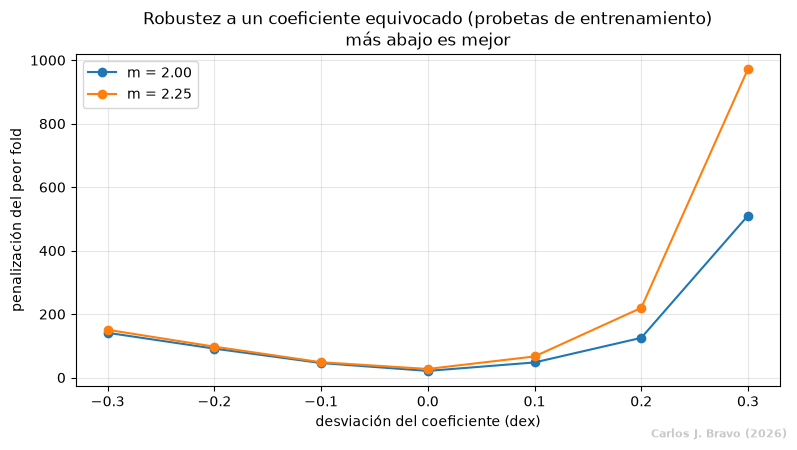

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for m, grupo in robustez_exponente.groupby("m"):
    ax.plot(grupo["delta_log10C"], grupo["peor_fold"], marker="o", label=f"m = {m:.2f}")
ax.set_xlabel("desviación del coeficiente (dex)")
ax.set_ylabel("penalización del peor fold")
ax.set_title("Robustez a un coeficiente equivocado (probetas de entrenamiento)\nmás abajo es mejor")
ax.legend()
ax.grid(alpha=0.3)
cerrar(fig)

Los dos exponentes se comportan de forma parecida mientras el coeficiente acierta, y se separan en
cuanto se desvía hacia arriba: el exponente mayor entra en la zona donde la solución cerrada cruza
cero en tiempo finito y la penalización se dispara. La elección responde al comportamiento del peor
caso, no a unas décimas de mejora nominal.

### 4.4 La cota de la extrapolación

La solución cerrada de Paris es monótona creciente y **no tiene cota superior**, de modo que un
coeficiente algo alto no produce un error algo mayor sino una grieta arbitrariamente larga. El
módulo de física ya recorta la trayectoria en 20 mm, pero ese valor no se eligió para la entrega:
se eligió para que la pérdida no desborde durante el entrenamiento, con el criterio explícito de
ser tan holgado que nunca tocase una curva razonable. Para un tope de entrega el criterio correcto
es el contrario, el mayor valor que el fenómeno produce de verdad, y esta etapa lo calibra.

La calibración tiene una trampa que hay que desactivar. La regla natural, la grieta más larga
observada en entrenamiento, vale 7.46 mm y procede de T1; evaluarla sobre el fold T1 sería
circular, porque la cota conocería la respuesta del espécimen que se puntúa. Por eso, en cada fold,
**la cota se recalcula excluyendo ese fold**, igual que se excluyen sus ondas del entrenamiento.
Al aplicarla a T7 y T8 la exclusión no procede: ninguno de los dos es un espécimen de
entrenamiento.

Se comparan dos cosas distintas. Un barrido de valores fijos, que describe la forma de la curva
pero **no es adoptable**, porque elegir su mínimo sería fijar un número mirando el resultado. Y un
conjunto de reglas que derivan la cota de los datos disponibles en cada fold, que sí lo es, porque
la misma regla puede aplicarse a T7 y T8 sin haberlos mirado.

In [12]:
t0 = time.perf_counter()
maximos = cota_extrapolacion.maximos_por_especimen([n for n in TRAIN_POOL])
print("grieta final medida (mm):", ", ".join(f"{n} {v:.2f}" for n, v in maximos.items()))
cache_cota = cota_extrapolacion.entrenar_folds(cfg_datos, n_seeds=3, etiquetas=etiquetas)
print(f"[{time.perf_counter() - t0:.0f} s]")

absoluto = cota_extrapolacion.barrido_absoluto(cache_cota, cfg_datos.m_exponent)
por_regla = cota_extrapolacion.barrido_por_regla(cache_cota, cfg_datos.m_exponent, maximos)
display(absoluto.round(2))
display(por_regla.drop(columns=["cota por fold (mm)"]).round(2))
print(por_regla[["regla", "cota por fold (mm)"]].to_string(index=False))

regla_elegida = por_regla.sort_values(["peor_fold_banda", "media_banda"]).iloc[0]["regla"]
cota_elegida = cota_extrapolacion.cota_de_regla(regla_elegida, maximos)
print(f"\nregla elegida: {regla_elegida}  ->  {cota_elegida:.2f} mm para T7 y T8")

grieta final medida (mm): T1 7.46, T2 4.95, T3 6.93, T4 7.24, T5 3.64, T6 5.08


  fold T1: estimador entrenado


  fold T3: estimador entrenado


  fold T4: estimador entrenado


  fold T6: estimador entrenado


[162 s]


,cota (mm),peor_fold_banda,media_banda,peor_fold_nominal,media_nominal,puntos_en_la_cota
0,4.0,204.48,121.85,204.48,120.64,94
1,5.0,141.17,54.99,75.60,48.08,72
2,6.0,141.17,35.65,31.26,21.75,47
3,7.0,141.17,32.41,21.64,13.75,33
4,7.5,141.17,33.93,19.27,13.69,28
5,8.0,141.17,36.52,21.01,14.12,26
6,9.0,141.17,41.39,21.11,14.15,17
7,10.0,141.17,45.68,21.11,14.15,14
8,12.0,141.17,54.17,21.11,14.15,9
9,15.0,282.99,65.80,21.11,14.15,3


,regla,cota para T7/T8 (mm),peor_fold_banda,media_banda,peor_fold_nominal,media_nominal
0,máxima observada,7.46,141.17,33.76,20.21,13.91
1,máxima observada +10 %,8.21,141.17,37.25,20.87,14.09
2,máxima observada +25 %,9.32,141.17,42.38,21.11,14.15
3,media de las máximas,5.88,141.17,40.45,39.41,28.96
4,segunda mayor,7.24,141.17,33.21,22.14,14.18
5,"sin cota (20 mm, actual)",20.00,510.42,80.69,21.11,14.15


                   regla                     cota por fold (mm)
        máxima observada     T1:7.24, T3:7.46, T4:7.46, T6:7.46
  máxima observada +10 %     T1:7.96, T3:8.21, T4:8.21, T6:8.21
  máxima observada +25 %     T1:9.05, T3:9.32, T4:9.32, T6:9.32
    media de las máximas     T1:5.57, T3:5.67, T4:5.61, T6:6.04
           segunda mayor     T1:6.93, T3:7.24, T4:6.93, T6:7.24
sin cota (20 mm, actual) T1:20.00, T3:20.00, T4:20.00, T6:20.00

regla elegida: segunda mayor  ->  7.24 mm para T7 y T8


Dos lecturas, y la primera es la que sostiene la decisión.

**El resultado no depende de acertar un número.** Todas las reglas sensatas empatan en el peor caso
sobre la banda, y todas mejoran la situación sin cota en torno a tres veces y media. Lo que el
criterio dice con claridad es que hay que poner una cota; cuál exactamente, dentro del rango
razonable, le resulta indiferente. Eso es mucho más robusto que un óptimo estrecho.

**El desempate es fino y se declara como tal.** Entre la mayor grieta observada y la segunda mayor
el peor caso es idéntico, y la segunda mayor queda algo por delante en la media sobre la banda. Se
adopta ésa, que sobre T1 a T6 vale 7.24 mm.

El alcance de esta cota es limitado y conviene acotarlo. **No modela el frenado de la segunda
probeta de validación ni predice su grieta final**: es una restricción de dominio sobre la salida,
justificada por el rango que el ensayo produce, que impide que una extrapolación sin cota superior
entregue longitudes que ninguna probeta alcanzó. Sigue sobrestimando; lo que evita es divergir.

### 4.5 La configuración que resulta

Las cuatro búsquedas anteriores fijan la duración del entrenamiento, los dos pesos del componente
físico, la ponderación de cada medida dentro de la pérdida, el exponente de la ley de crecimiento y
el origen del coeficiente con el que se extrapola y la cota de la extrapolación. La configuración que se entrena en el apartado 5
es la que sale de ellas, sin retoques posteriores.

In [13]:
decidido = {
    "duración y pesos físicos": {k: tabla_capacidad.iloc[0][k] for k in GRID},
    "peso por medida": peso_elegido,
    "exponente y coeficiente": prognosis_elegida,
    "cota de extrapolación": {"regla": regla_elegida, "mm": round(cota_elegida, 2)},
}
for etapa, valores in decidido.items():
    print(f"{etapa:28s} {valores}")

LAMBDA_FISICO = 1.0
mejor = tabla_capacidad.iloc[0]
print(f"{'peso del término físico':28s} "
      f"adoptado {LAMBDA_FISICO}, "
      f"elegido por la búsqueda {float(mejor['lambda_physics'])}")
cfg = Config(**{**BASE,
                **peso_elegido,
                "epochs": int(mejor["epochs"]),
                "dropout": float(mejor["dropout"]),
                "weight_decay": float(mejor["weight_decay"]),
                "lambda_physics": LAMBDA_FISICO,
                "lambda_log_c_prior": float(mejor["lambda_log_c_prior"]),
                "data_loss": str(mejor["data_loss"]),
                "m_exponent": prognosis_elegida["m_exponent"],
                "cota_entrega_mm": cota_elegida})
print()
display(pd.DataFrame([{"parámetro": k, "valor": v} for k, v in asdict(cfg).items()]))

if abs(cfg.m_exponent - cfg_datos.m_exponent) > 1e-9:
    lotes = build_specimen_batches(etiquetas, cfg.m_exponent)
    print(f"lotes reconstruidos al exponente elegido, m = {cfg.m_exponent}")

duración y pesos físicos     {'m_exponent': np.float64(2.0), 'epochs': np.int64(600), 'dropout': np.float64(0.3), 'weight_decay': np.float64(0.001), 'lambda_physics': np.float64(3.0), 'lambda_log_c_prior': np.float64(1.0), 'data_loss': 'asym'}
peso por medida              {'data_weight': 'anchor', 'anchor_weight': 48.0}
exponente y coeficiente      {'m_exponent': 2.0, 'fuente_coeficiente': 'cabeza'}
cota de extrapolación        {'regla': 'segunda mayor', 'mm': 7.24}
peso del término físico      adoptado 1.0, elegido por la búsqueda 3.0



,parámetro,valor
0,m_exponent,2.0
1,log_c_prior,-8.426375
2,log_c_range,1.0
3,log_c_prior_sd,0.3
4,lambda_log_c_prior,1.0
5,data_loss,asym
6,data_weight,anchor
7,anchor_weight,48.0
8,n_anchor,2
9,lambda_physics,1.0


La búsqueda de capacidad selecciona un peso del término físico superior al que esta configuración
adopta. Se conserva el valor 1.0 por una razón que está fuera del alcance de este cuaderno: las
Configuraciones 2, 3 y 4 se construyen sobre esta misma base y se comparan con ella, de modo que
alterarla invalidaría esa comparación. La diferencia entre ambos valores sobre las probetas de
validación es menor que el recorrido que produce cambiar la semilla, de manera que la elección no
condiciona los resultados que siguen.

### 4.6 Los pesos que no se eligen

Dos pesos de la pérdida no entran en ninguna búsqueda: el de la bisagra que penaliza los retrocesos
de la curva y la fracción del entrenamiento que transcurre antes de que el término físico empiece a
actuar. Ambos son valores heredados, y la medida que sigue cuantifica si mueven el resultado.

La medida emplea varias tandas de semillas independientes, porque con este tamaño de muestra un
ensamblado no es una constante y comparar dos valores con una sola tanda cada uno no separa el
efecto del ruido de semilla.

In [14]:
t0 = time.perf_counter()
tabla_sensibilidad = sensibilidad.sensibilidad_pesos(n_tandas=3, etiquetas=etiquetas, base=cfg)
print(f"\n[{time.perf_counter() - t0:.0f} s]")
resumen_sens = (tabla_sensibilidad.groupby(["peso", "valor"])
                .agg(T7_mediana=("T7", "median"), T7_min=("T7", "min"), T7_max=("T7", "max"),
                     T8_mediana=("T8", "median"))
                .round(2).reset_index())
display(resumen_sens)
for peso, grupo in resumen_sens.groupby("peso"):
    entre = grupo["T7_mediana"].max() - grupo["T7_mediana"].min()
    dentro = (grupo["T7_max"] - grupo["T7_min"]).max()
    print(f"{peso:22s} recorrido entre valores {entre:6.2f}   dentro de un mismo valor {dentro:6.2f}")

  lambda_monotonic       = 0.0   tanda 0  T7     6.26


  lambda_monotonic       = 0.0   tanda 1  T7     5.56


  lambda_monotonic       = 0.0   tanda 2  T7     5.53


  lambda_monotonic       = 0.5   tanda 0  T7     6.49


  lambda_monotonic       = 0.5   tanda 1  T7     5.58


...

  physics_warmup_frac    = 0.5   tanda 1  T7     5.10


  physics_warmup_frac    = 0.5   tanda 2  T7     6.62



[1511 s]


,peso,valor,T7_mediana,T7_min,T7_max,T8_mediana
0,lambda_monotonic,0.00,5.56,5.53,6.26,91.29
1,lambda_monotonic,0.50,6.49,5.58,7.41,91.06
2,lambda_monotonic,2.00,5.54,5.25,6.65,90.80
3,physics_warmup_frac,0.00,5.50,4.97,5.82,90.70
4,physics_warmup_frac,0.25,6.49,5.58,7.41,91.06
5,physics_warmup_frac,0.50,5.27,5.10,6.62,91.42


lambda_monotonic       recorrido entre valores   0.95   dentro de un mismo valor   1.83
physics_warmup_frac    recorrido entre valores   1.22   dentro de un mismo valor   1.83


Las dos últimas cifras resumen el resultado: el recorrido **dentro** de un mismo valor, que es ruido
de semilla, supera al recorrido **entre** valores distintos. Ninguno de los dos pesos mueve el
resultado por encima del ruido, de modo que los valores heredados se mantienen y no se presentan
como elegidos.

## 5. Entrenamiento

Se entrena sobre las seis probetas de entrenamiento, sin excluir ninguna, y se ensamblan cinco
semillas independientes. Promediar unas pocas semillas es el regularizador más fiable disponible a
este tamaño de muestra: ejecuciones individuales sobre sesenta o setenta ondas caen en mínimos
visiblemente distintos, y la media de sus predicciones es consistentemente mejor que cualquiera de
ellas. No cuesta nada en inferencia y no toca las probetas de validación.

El entrenamiento agota su presupuesto de épocas, sin detención automática. La alternativa, vigilar
una probeta retenida del propio conjunto de entrenamiento y detenerse cuando su pérdida deja de
bajar, está medida sobre tres tandas de semillas y empeora el resultado: esa pérdida alcanza su
mínimo entre las épocas seis y cuarenta y tres y después sube, mientras el modelo sigue mejorando en
lo que el certamen puntúa. Con seis probetas y un salto grande entre ellas, esa curva contiene más
ruido que señal.

In [ ]:
nombres_entrenamiento = [n for n in TRAIN_POOL if n in lotes]
modelos, segundos, procedencia = cargar_o_entrenar(
    "config1/conjunto", cfg,
    lambda: train_ensemble(cfg, lotes, nombres_entrenamiento, n_seeds=5, verbose=True),
    forzar=ENTRENAR_DE_NUEVO, entrenados_sobre=nombres_entrenamiento,
    notas="Conjunto de 5 semillas de la configuración adoptada.")
print(f"\n{len(modelos)} modelos sobre {', '.join(nombres_entrenamiento)} "
      f"en {segundos:.0f} s ({procedencia})")


### 5.1 Evolución de la pérdida durante el entrenamiento

Cada término de la pérdida aparece dos veces: su valor crudo, que mide el desajuste, y su
contribución efectiva al gradiente, ya multiplicada por su peso y, en el término físico, por la
rampa de entrada. Sin esa distinción el término físico aparentaría estar activo desde la primera
época, cuando su peso es todavía exactamente cero y no toca el gradiente.

Las curvas corresponden a la primera de las cinco semillas del ensamblado.

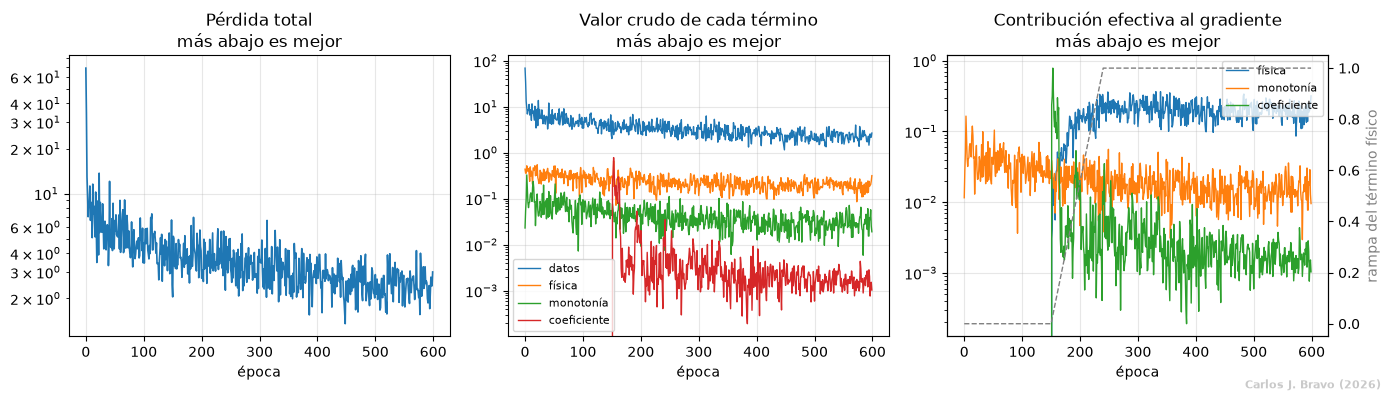

In [16]:
historia = pd.DataFrame(modelos[0].history_terms)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(historia["epoch"], historia["total"], lw=1.2)
axes[0].set_yscale("log")
axes[0].set_title("Pérdida total\nmás abajo es mejor")
axes[0].set_xlabel("época")
axes[0].grid(alpha=0.3)

for columna, etiqueta in [("data", "datos"), ("physics", "física"),
                          ("mono", "monotonía"), ("prior", "coeficiente")]:
    axes[1].plot(historia["epoch"], historia[columna], lw=1.0, label=etiqueta)
axes[1].set_yscale("log")
axes[1].set_title("Valor crudo de cada término\nmás abajo es mejor")
axes[1].set_xlabel("época")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

for columna, etiqueta in [("physics_eff", "física"), ("mono_eff", "monotonía"),
                          ("prior_eff", "coeficiente")]:
    axes[2].plot(historia["epoch"], historia[columna], lw=1.0, label=etiqueta)
eje_peso = axes[2].twinx()
eje_peso.plot(historia["epoch"], historia["physics_weight"], lw=1.0, ls="--", color="0.5")
eje_peso.set_ylabel("rampa del término físico", color="0.5")
axes[2].set_yscale("log")
axes[2].set_title("Contribución efectiva al gradiente\nmás abajo es mejor")
axes[2].set_xlabel("época")
axes[2].legend(fontsize=8, loc="upper right")
axes[2].grid(alpha=0.3)

cerrar(fig)

## 6. Resultados sobre T7 y T8

Las dos probetas de validación se cargan en este apartado y en ninguno anterior.

La métrica principal es la penalización oficial del certamen, y la secundaria el error cuadrático
medio en milímetros. Ambas se informan **por probeta**: un resultado de una probeta y la suma de dos
no son magnitudes comparables, y las publicaciones del certamen mezclan ambas formas.

La entrega se construye según el protocolo. Hasta el último ciclo con señal, la grieta se lee de la
onda. A partir de ahí la curva se propaga hacia delante con la ley de Paris, arrancando de la última
estimación y usando el coeficiente que la cabeza física identificó para esa probeta. La única
corrección posterior es forzar la monotonía sobre la mitad estimada; la extrapolada ya es monótona
por construcción.

In [17]:
entregas = [build_submission(modelos, lotes, cfg, nombre) for nombre in ("T7", "T8")]
display(summarise(entregas))

,espécimen,RMSE (mm),penalización,de la estimación,de la prognosis,log10 C predicho,log10 C implicado,correcciones monotonía
0,T7,0.3500,6.485,1.593,4.892,-8.423,-8.420,0
1,T8,2.4176,90.451,5.384,85.068,-8.423,-8.803,0


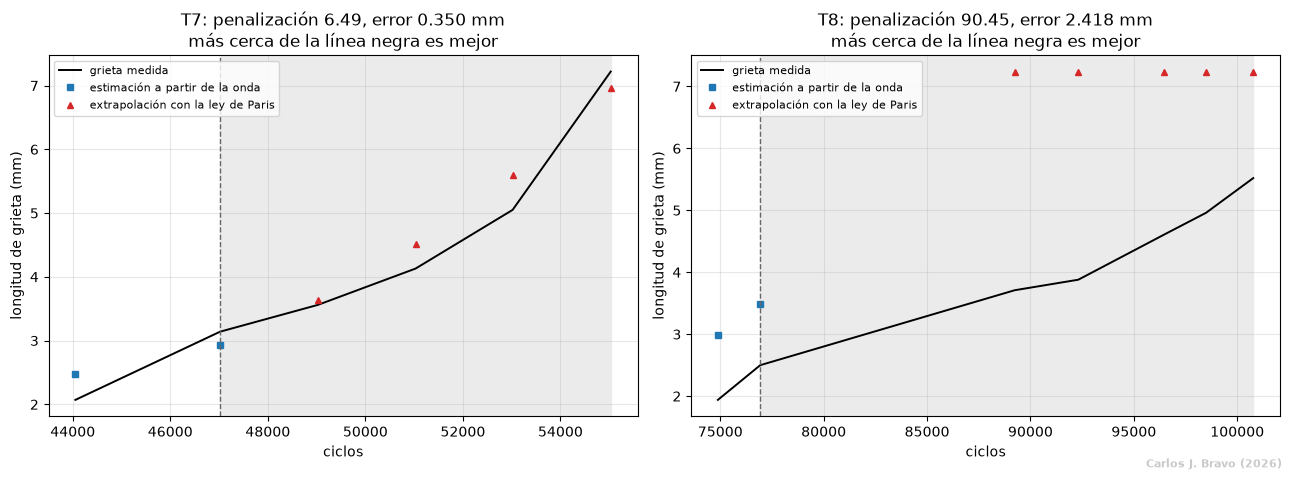

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, entrega in zip(axes, entregas):
    ciclos = np.array(entrega["cycles"])
    real = np.array(entrega["true_mm"])
    predicho = np.array(entrega["pred_mm"])
    origen = np.array(entrega["source"])
    corte = entrega["cutoff_cycle"]
    estimado = origen == "estimación 1D-CNN"

    ax.axvspan(corte, ciclos.max(), color="0.92")
    ax.plot(ciclos, real, "k-", lw=1.4, label="grieta medida")
    ax.plot(ciclos[estimado], predicho[estimado], "s", ms=5, color="tab:blue",
            label="estimación a partir de la onda")
    ax.plot(ciclos[~estimado], predicho[~estimado], "^", ms=5, color="tab:red",
            label="extrapolación con la ley de Paris")
    ax.axvline(corte, color="0.4", lw=1.0, ls="--")
    ax.set_title(f"{entrega['specimen']}: penalización {entrega['penalizacion']:.2f}, "
                 f"error {entrega['rmse_mm']:.3f} mm\nmás cerca de la línea negra es mejor")
    ax.set_xlabel("ciclos")
    ax.set_ylabel("longitud de grieta (mm)")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.3)
cerrar(fig)

In [19]:
filas = []
for entrega in entregas:
    origen = np.array(entrega["source"])
    total = entrega["penalizacion"]
    filas.append({
        "espécimen": entrega["specimen"],
        "ciclos estimados": int((origen == "estimación 1D-CNN").sum()),
        "ciclos extrapolados": int((origen == "extrapolación Paris").sum()),
        "penalización de la estimación": round(entrega["penalizacion_estimacion"], 2),
        "penalización de la prognosis": round(entrega["penalizacion_prognosis"], 2),
        "fracción que viene de la prognosis": f"{100 * entrega['penalizacion_prognosis'] / total:.1f} %",
    })
display(pd.DataFrame(filas))

diagnostico = pd.concat(
    [coefficient_diagnostic(modelos, lotes, cfg, n) for n in ("T7", "T8")],
    ignore_index=True)
display(diagnostico)

resultado = pd.DataFrame([{
    "T7": round(entregas[0]["penalizacion"], 2),
    "T8": round(entregas[1]["penalizacion"], 2),
    "penalización T7+T8": round(sum(e["penalizacion"] for e in entregas), 2),
}])
print(tabla_comparativa(resultado))

,espécimen,ciclos estimados,ciclos extrapolados,penalización de la estimación,penalización de la prognosis,fracción que viene de la prognosis
0,T7,2,4,1.59,4.89,75.4 %
1,T8,2,5,5.38,85.07,94.0 %


,espécimen,coeficiente,log10 C,penalización,RMSE (mm)
0,T7,C predicho por el PINN,-8.423,6.49,0.350
1,T7,C implicado por la verdad (oráculo),-8.420,6.22,0.354
2,T8,C predicho por el PINN,-8.423,90.45,2.418
3,T8,C implicado por la verdad (oráculo),-8.803,70.25,2.008


                                            T7         T8      total
  Configuración 1 (este trabajo)          6.49      90.45      96.94
  1.º Youn et al. (2019) (publicado)      3.42       3.94       7.36
  2.º Kong et al. (2020) (publicado)      3.54       4.09       7.63
  3.º Rao et al. (2020) (publicado)       9.23       6.86      16.09
  1.º Youn et al. (2019) (réplica local)     22.71      91.60     114.31
  2.º Kong et al. (2020) (réplica local)     83.25     148.34     231.60
  3.º Rao et al. (2020) (réplica local)    215.12      25.79     240.91

  n/d: el paper del 1.º publica su score en mm crudos, no la
       penalización normalizada por espécimen.


## 7. Atribución del error

### 7.1 Atribución entre estimador y coeficiente

La entrega tiene dos piezas encadenadas, y la penalización final no indica cuál de las dos falla.
Para separarlas se **congela el modelo ya entrenado** y se recorre únicamente el coeficiente con el
que se extrapola, reconstruyendo la entrega con cada valor. Al variar una sola cantidad, la
atribución queda determinada.

Las dos filas de la tabla se construyen bajo la **misma cota de entrega** que la entrega oficial.
Evaluar la fila del coeficiente verdadero sin esa cota exageraría lo que aporta acertarlo, porque
le atribuiría también el daño que la cota ya evita: ambos mecanismos actúan sobre la misma
sobrestimación y se solapan. Medidos por separado, sobre la segunda probeta la cota lleva la
penalización de varios miles a noventa, y acertar el coeficiente sobre esa base la lleva de noventa
a setenta. La comparación honesta es la segunda.

El barrido cuantifica además el requisito que hereda la Configuración 3: con qué precisión hay que
acertar el coeficiente para que la entrega describa la curva en lugar de acotarla.

In [20]:
t0 = time.perf_counter()
tabla_coeficiente, barridos, curvas_coeficiente = verificar_coeficiente(modelos, lotes, cfg)
print(f"\n[{time.perf_counter() - t0:.0f} s]")
display(tabla_coeficiente)


=== T7 ===
  log10 C predicho por el modelo : -8.423  -> RMSE  0.350 mm, penalización      6.49
  log10 C óptimo (barrido)       : -8.435  -> RMSE  0.344 mm, penalización      7.76
  log10 C de mínima penalización : -8.405  -> RMSE  0.395 mm, penalización      4.85
  banda con RMSE <= 1 mm         : [-8.635, -8.290]  (anchura 0.345 dex)
  el modelo cae DENTRO de esa banda

=== T8 ===
  log10 C predicho por el modelo : -8.423  -> RMSE  2.418 mm, penalización     90.45
  log10 C óptimo (barrido)       : -9.230  -> RMSE  0.644 mm, penalización     17.58
  log10 C de mínima penalización : -9.135  -> RMSE  0.704 mm, penalización     14.34
  banda con RMSE <= 1 mm         : [-9.600, -9.025]  (anchura 0.575 dex)
  el modelo cae FUERA por 0.602 dex de esa banda

[0 s]


,espécimen,log10 C predicho,RMSE con el predicho (mm),penalización con el predicho,log10 C óptimo,RMSE con el óptimo (mm),penalización con el óptimo,banda RMSE<=1mm (dex)
0,T7,-8.423,0.350,6.49,-8.435,0.344,7.76,0.345
1,T8,-8.423,2.418,90.45,-9.230,0.644,17.58,0.575


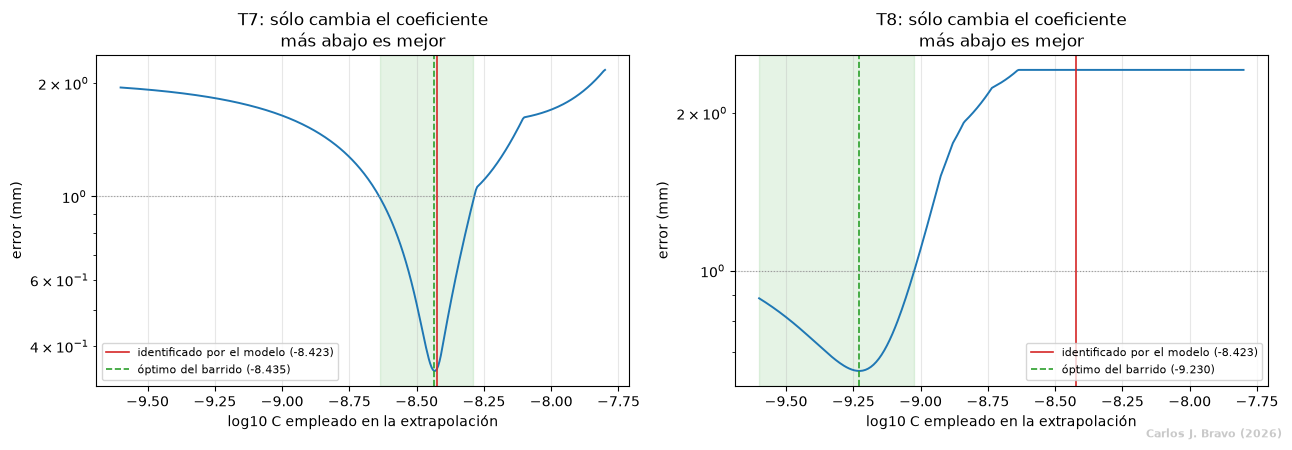

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (nombre, barrido) in zip(axes, barridos.items()):
    entrega = barrido.attrs["submission"]
    ax.plot(barrido["log10_C"], barrido["rmse_mm"], lw=1.4)
    ax.axhline(1.0, color="0.6", lw=0.8, ls=":")
    ax.axvline(entrega["log10_C_predicho"], color="tab:red", lw=1.2,
               label=f"identificado por el modelo ({entrega['log10_C_predicho']:.3f})")
    mejor = barrido.loc[barrido["rmse_mm"].idxmin(), "log10_C"]
    ax.axvline(mejor, color="tab:green", lw=1.2, ls="--",
               label=f"óptimo del barrido ({mejor:.3f})")
    banda = barrido.loc[barrido["rmse_mm"] <= 1.0, "log10_C"]
    if len(banda):
        ax.axvspan(banda.min(), banda.max(), color="tab:green", alpha=0.12)
    ax.set_yscale("log")
    ax.set_xlabel("log10 C empleado en la extrapolación")
    ax.set_ylabel("error (mm)")
    ax.set_title(f"{nombre}: sólo cambia el coeficiente\nmás abajo es mejor")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
cerrar(fig)

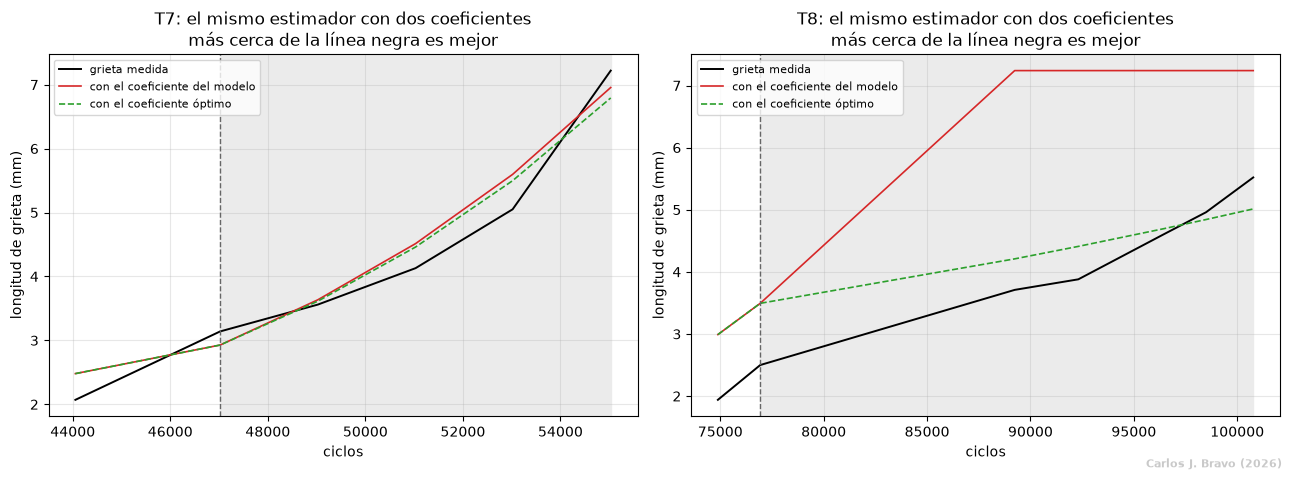

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, (nombre, curva) in zip(axes, curvas_coeficiente.items()):
    ciclos = np.array(curva["cycles"])
    ax.axvspan(curva["cutoff_cycle"], ciclos.max(), color="0.92")
    ax.plot(ciclos, curva["true_mm"], "k-", lw=1.4, label="grieta medida")
    ax.plot(ciclos, curva["pred_predicho"], lw=1.2, color="tab:red",
            label="con el coeficiente del modelo")
    ax.plot(ciclos, curva["pred_optimo"], lw=1.2, ls="--", color="tab:green",
            label="con el coeficiente óptimo")
    ax.axvline(curva["cutoff_cycle"], color="0.4", lw=1.0, ls="--")
    ax.set_xlabel("ciclos")
    ax.set_ylabel("longitud de grieta (mm)")
    ax.set_title(f"{nombre}: el mismo estimador con dos coeficientes\n"
                 f"más cerca de la línea negra es mejor")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.3)
cerrar(fig)

El barrido separa tres coeficientes distintos. El que el modelo emite, el que
implica la curva completa de cada probeta, y el que minimiza el error de la entrega. Sobre la
primera probeta los tres casi coinciden y la cota nunca llega a actuar. Sobre la segunda están
separados por más de ocho décimas de década entre el primero y el último, y de ahí sale tanto la
saturación de su extrapolación como el margen que queda por recorrer.

### 7.2 Procedencia de las constantes de fractura

La identificación de las constantes es una parte cara del trabajo, y su alternativa es tomar un par
publicado. El experimento construye la misma configuración, con la misma arquitectura, la misma
pérdida, el mismo protocolo y las mismas semillas, cambiando **sólo de dónde salen el exponente y el
coeficiente**.

Las procedencias comparadas son la identificación propia, la ventana genérica de metales que usa una
de las entradas del certamen, un par publicado para este mismo aluminio en aire, un ajuste para el
mismo aluminio en otro temple y geometría, y el ajuste de la administración aeronáutica
estadounidense para chapa de este material, única constante del conjunto con unidades explícitas y
por tanto única comparación sin ambigüedad dimensional.

In [23]:
for nombre, especificacion in SOURCES.items():
    print(f"  {nombre}\n      {especificacion['procedencia']}")
t0 = time.perf_counter()
tabla_procedencias, detalle_procedencias = comparar_procedencias(n_seeds=5)
print(f"\n[{time.perf_counter() - t0:.0f} s]")
display(tabla_procedencias)

  Identificado, m = 2,25 (minimax en entrenamiento)
      Este trabajo, physics_calibration/
  Identificado, m = 2,00 (forma cerrada no singular)
      Este trabajo, criterio estructural
  Literatura — Rao et al. (ventana metálica genérica)
      3.er puesto PHM 2019, tras Li, Wang & Gong (2012)
  Literatura — Dourado & Viana (Al 2024-T3, aire)
      PHM Conf. 2019, cupones de Menan & Henaff (2010)
  Literatura — FAA FCGD, Walker 2024-T3 chapa (Forman et al., 2005)
      DOT/FAA/AR-05/15, fig. 3 (M2EA11AB1), convertido a SI con R = 0,0476
  Literatura — Metals 2023 (AA 2024-T4, CT, R=-1)
      Metals 13(8):1134 (2023)

=== Identificado, m = 2,25 (minimax en entrenamiento) ===
    m = 2.250   log10 C = -8.668 (C = 2.150e-09)   [Este trabajo, physics_calibration/]


    T7 =     5.16 (RMSE 0.429 mm)   T8 =      90.45 (RMSE 2.418 mm)   total =      95.62

=== Identificado, m = 2,00 (forma cerrada no singular) ===
    m = 2.000   log10 C = -8.425 (C = 3.758e-09)   [Este trabajo, criterio estructural]


    T7 =     5.60 (RMSE 0.364 mm)   T8 =      90.46 (RMSE 2.418 mm)   total =      96.06

=== Literatura — Rao et al. (ventana metálica genérica) ===
    m = 3.000   log10 C = -12.000 (C = 1.000e-12)   [3.er puesto PHM 2019, tras Li, Wang & Gong (2012)]


    T7 =   289.55 (RMSE 2.108 mm)   T8 =     111.28 (RMSE 1.151 mm)   total =     400.83

=== Literatura — Dourado & Viana (Al 2024-T3, aire) ===
    m = 3.859   log10 C = -9.300 (C = 5.008e-10)   [PHM Conf. 2019, cupones de Menan & Henaff (2010)]


    T7 =    31.77 (RMSE 2.176 mm)   T8 =      89.85 (RMSE 2.406 mm)   total =     121.61

=== Literatura — FAA FCGD, Walker 2024-T3 chapa (Forman et al., 2005) ===
    m = 3.273   log10 C = -10.480 (C = 3.312e-11)   [DOT/FAA/AR-05/15, fig. 3 (M2EA11AB1), convertido a SI con R = 0,0476]


    T7 =   202.06 (RMSE 1.832 mm)   T8 =      14.17 (RMSE 0.683 mm)   total =     216.23

=== Literatura — Metals 2023 (AA 2024-T4, CT, R=-1) ===
    m = 3.090   log10 C = -7.240 (C = 5.750e-08)   [Metals 13(8):1134 (2023)]


    T7 =    31.69 (RMSE 2.175 mm)   T8 =      90.12 (RMSE 2.411 mm)   total =     121.81

[509 s]


,procedencia de m y C,m,log10 C,T7,T8,total,RMSE T7 (mm),RMSE T8 (mm)
0,"Identificado, m = 2,25 (minimax en entrenamiento)",2.250,-8.668,5.16,90.45,95.62,0.429,2.418
1,"Identificado, m = 2,00 (forma cerrada no singu...",2.000,-8.425,5.60,90.46,96.06,0.364,2.418
2,Literatura — Rao et al. (ventana metálica gené...,3.000,-12.000,289.55,111.28,400.83,2.108,1.151
3,"Literatura — Dourado & Viana (Al 2024-T3, aire)",3.859,-9.300,31.77,89.85,121.61,2.176,2.406
4,"Literatura — FAA FCGD, Walker 2024-T3 chapa (F...",3.273,-10.480,202.06,14.17,216.23,1.832,0.683
5,"Literatura — Metals 2023 (AA 2024-T4, CT, R=-1)",3.090,-7.240,31.69,90.12,121.81,2.175,2.411


La tabla anterior se puntúa sobre las probetas de validación, de modo que describe el efecto pero
no decide: adoptar una constante porque puntúa bien en una de ellas equivaldría a elegir con la
probeta que se juzga. La decisión se toma con el mismo criterio sin fuga que el apartado 4, sobre probetas
de entrenamiento y sobre toda la banda de incertidumbre del coeficiente.

In [24]:
t0 = time.perf_counter()
tabla_robustez, detalle_robustez = robustez_constantes(n_seeds=3, etiquetas=etiquetas)
print(f"\n[{time.perf_counter() - t0:.0f} s]")
display(tabla_robustez.round(2))


Identificado, m = 2,00: estimadores entrenados (m = 2.000)


  [cabeza]
           procedencia coeficiente  delta_log10C  media  peor_fold  puntos_en_tope
Identificado, m = 2,00      cabeza          -0.3  72.30     141.17               0
Identificado, m = 2,00      cabeza          -0.2  45.79      91.32               0
Identificado, m = 2,00      cabeza          -0.1  21.73      45.86               0
Identificado, m = 2,00      cabeza           0.0  14.15      21.11               0
Identificado, m = 2,00      cabeza           0.1  29.61      47.75               0
Identificado, m = 2,00      cabeza           0.2  77.77     125.23               0
Identificado, m = 2,00      cabeza           0.3 303.49     510.42               0



FAA 2024-T3 chapa (Forman et al., 2005): estimadores entrenados (m = 3.273)


  [cabeza]
                            procedencia coeficiente  delta_log10C  media  peor_fold  puntos_en_tope
FAA 2024-T3 chapa (Forman et al., 2005)      cabeza          -0.3 226.19     369.57               0
FAA 2024-T3 chapa (Forman et al., 2005)      cabeza          -0.2 217.02     357.24               0
FAA 2024-T3 chapa (Forman et al., 2005)      cabeza          -0.1 205.62     341.77               0
FAA 2024-T3 chapa (Forman et al., 2005)      cabeza           0.0 191.53     322.37               0
FAA 2024-T3 chapa (Forman et al., 2005)      cabeza           0.1 174.23     298.15               0
FAA 2024-T3 chapa (Forman et al., 2005)      cabeza           0.2 153.26     268.07               0
FAA 2024-T3 chapa (Forman et al., 2005)      cabeza           0.3 128.16     231.08               0


  [fijo]
                            procedencia coeficiente  delta_log10C  media  peor_fold  puntos_en_tope
FAA 2024-T3 chapa (Forman et al., 2005)        fijo          -0.3 226.65     370.26               0
FAA 2024-T3 chapa (Forman et al., 2005)        fijo          -0.2 217.60     358.12               0
FAA 2024-T3 chapa (Forman et al., 2005)        fijo          -0.1 206.34     342.87               0
FAA 2024-T3 chapa (Forman et al., 2005)        fijo           0.0 192.41     323.75               0
FAA 2024-T3 chapa (Forman et al., 2005)        fijo           0.1 175.32     299.87               0
FAA 2024-T3 chapa (Forman et al., 2005)        fijo           0.2 154.57     270.19               0
FAA 2024-T3 chapa (Forman et al., 2005)        fijo           0.3 129.72     233.67               0



[334 s]


,procedencia,coeficiente,m,media_nominal,peor_fold_nominal,peor_fold_banda,puntos_en_tope_banda
0,"FAA 2024-T3 chapa (Forman et al., 2005)",cabeza,3.27,191.53,322.37,369.57,0
1,"FAA 2024-T3 chapa (Forman et al., 2005)",fijo,3.27,192.41,323.75,370.26,0
2,"Identificado, m = 2,00",cabeza,2.00,14.15,21.11,510.42,0


## 8. El coeficiente que T8 habría necesitado

El apartado anterior localiza el error en el coeficiente con el que se extrapola. Este cuantifica
cuánto margen queda ahí: con el estimador congelado y sustituyendo únicamente ese coeficiente, qué
resultado alcanzaría la entrega.

Se comparan cuatro valores, y conviene no confundirlos porque responden a preguntas distintas:

| Coeficiente | Qué representa |
|---|---|
| **Emitido por el modelo** | lo que la cabeza física identifica a partir de las ondas, que es lo único disponible al predecir |
| **Implicado por la curva** | el que mejor describe la curva medida completa de la probeta |
| **De mínimo error** | el que deja la curva entregada más cerca de la real en milímetros |
| **De mínima penalización** | el que obtiene la mejor puntuación oficial, que no coincide con el anterior porque la métrica castiga de forma desigual quedarse corto y pasarse |

Los dos últimos sólo pueden obtenerse mirando la curva real de T8, que es lo que el certamen pide
predecir. **Ninguno de los resultados de este apartado es una predicción**: miden el techo que
alcanzaría esta configuración si un mecanismo futuro lograse identificar el coeficiente correcto a
partir de información disponible en el momento de predecir.

In [25]:
barrido_t8 = barridos["T8"]
entrega_t8 = entregas[1]
curva_t8 = load_curve("T8")

candidatos = {
    "emitido por el modelo": entrega_t8["log10_C_predicho"],
    "implicado por la curva": entrega_t8["log10_C_implicado"],
    "de mínimo error": float(barrido_t8.loc[barrido_t8["rmse_mm"].idxmin(), "log10_C"]),
    "de mínima penalización": float(barrido_t8.loc[barrido_t8["penalizacion"].idxmin(), "log10_C"]),
}

filas = []
for nombre, log_c in candidatos.items():
    pred = trajectory(modelos, lotes, cfg, "T8", log_c)
    filas.append({
        "coeficiente": nombre,
        "log10 C": round(log_c, 3),
        "C": f"{10 ** log_c:.3e}",
        "penalización T8": round(float(phm_penalty(
            pred[None, :], curva_t8.crack_mm, curva_t8.final_crack_mm)[0]), 2),
        "error (mm)": round(float(np.sqrt(np.mean((pred - curva_t8.crack_mm) ** 2))), 3),
        "grieta final predicha (mm)": round(float(pred[-1]), 2),
        "total T7+T8": round(entregas[0]["penalizacion"] + float(phm_penalty(
            pred[None, :], curva_t8.crack_mm, curva_t8.final_crack_mm)[0]), 2),
    })
tabla_margen = pd.DataFrame(filas)
display(tabla_margen)
print(f"grieta final medida en T8: {curva_t8.crack_mm[-1]:.2f} mm")
print(f"distancia del coeficiente emitido al de mínima penalización: "
      f"{abs(candidatos['emitido por el modelo'] - candidatos['de mínima penalización']):.3f} dex")

,coeficiente,log10 C,C,penalización T8,error (mm),grieta final predicha (mm),total T7+T8
0,emitido por el modelo,-8.423,3.774e-09,90.45,2.418,7.24,96.94
1,implicado por la curva,-8.803,1.572e-09,70.25,2.008,7.24,76.73
2,de mínimo error,-9.230,5.888e-10,17.58,0.644,5.01,24.07
3,de mínima penalización,-9.135,7.328e-10,14.34,0.704,5.48,20.83


grieta final medida en T8: 5.52 mm
distancia del coeficiente emitido al de mínima penalización: 0.712 dex


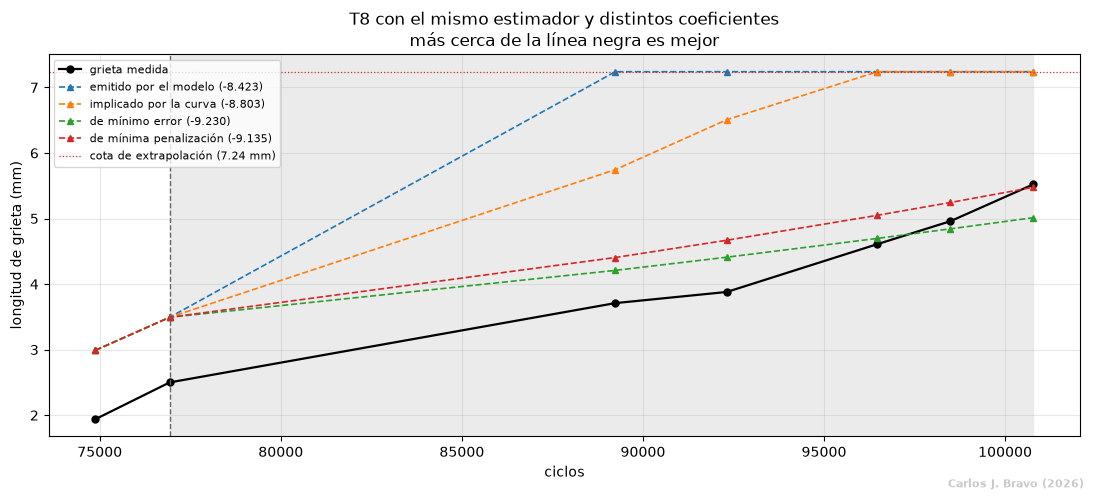

In [26]:
fig, ax = plt.subplots(figsize=(11, 5))
ciclos = np.array(entrega_t8["cycles"], dtype=float)
corte = entrega_t8["cutoff_cycle"]
ax.axvspan(corte, ciclos.max(), color="0.92")
ax.plot(ciclos, entrega_t8["true_mm"], "k-o", lw=1.6, ms=5, label="grieta medida")
for nombre, log_c in candidatos.items():
    ax.plot(ciclos, trajectory(modelos, lotes, cfg, "T8", log_c), "--^", lw=1.2, ms=4,
            label=f"{nombre} ({log_c:.3f})")
ax.axvline(corte, color="0.4", lw=1.0, ls="--")
ax.axhline(cfg.cota_entrega_mm, color="tab:red", lw=0.9, ls=":",
           label=f"cota de extrapolación ({cfg.cota_entrega_mm:.2f} mm)")
ax.set_xlabel("ciclos")
ax.set_ylabel("longitud de grieta (mm)")
ax.set_title("T8 con el mismo estimador y distintos coeficientes\nmás cerca de la línea negra es mejor")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3)
cerrar(fig)

### 8.1 Por qué no se alcanza ese coeficiente

El margen es amplio y está fuera de alcance por tres razones que el trabajo deja medidas.

**En la ventana con señal, T8 no se distingue de una probeta de amplitud constante.** El
coeficiente que implican sus medidas observadas coincide, hasta la milésima de década, con el de la
probeta T7. Toda la anomalía se manifiesta en el tramo sin señal, de modo que ninguna información
disponible en el momento de predecir la anticipa.

**T8 se frena donde la ley exige acelerar.** Su velocidad de crecimiento en el tramo ciego cae
aproximadamente a la mitad de la que traía, mientras que la ley de Paris, al crecer la grieta, sólo
puede acelerar. Ninguna elección del coeficiente reproduce ambas mitades a la vez: el de mínima
penalización acierta el tramo final a costa de describir mal el observado.

**La carga por bloques explica una parte pequeña de la diferencia.** El rango de tensión
equivalente ya la contabiliza, y los mecanismos documentados para amplitud variable cubren en
conjunto alrededor de una cuarta parte de la desviación. El resto corresponde a un comportamiento
que este conjunto de datos no permite modelar, porque **ninguna otra probeta comparte el régimen de
carga de T8**: siete de las ocho son de amplitud constante.

De ahí el requisito que heredan las configuraciones siguientes, y que fija el objetivo de forma
cuantitativa: identificar el coeficiente con una precisión que el estimador actual no alcanza, o
sustituir la extrapolación analítica por un mecanismo capaz de representar una desaceleración.

## 9. Conclusiones

**Lo que esta configuración sostiene.** La preparación de la señal y la ponderación de las medidas
que sirven de ancla son las dos decisiones que mueven el resultado, muy por delante de cualquier
detalle de la arquitectura. La pérdida de entrenamiento incorpora la misma asimetría que el certamen
aplica al puntuar, en lugar de corregirla a posteriori, que es la vía por la que este trabajo
responde a la primera de las lagunas de investigación señaladas en el estado del arte. Sobre T7 el
resultado queda por delante del tercer clasificado publicado y de las tres réplicas locales, y el
total queda por delante de las tres réplicas.

**Lo que no sostiene.** Frente a los resultados publicados del certamen, esta configuración pierde,
y sin la restricción de dominio del apartado 4.4 la segunda probeta divergiría. La aportación de
cada término de la pérdida por separado no se somete aquí a prueba: la arquitectura está fijada por
el diseño del estudio, codificador convolucional más módulo físicamente informado, y es la base
sobre la que se construyen las Configuraciones 2 a 4, de modo que la comparación pertinente es entre
configuraciones y no dentro de ésta.

**Qué es y qué no es la cota de extrapolación.** Es una restricción de dominio, no un modelo. En T8
la extrapolación supera el límite antes del primer ciclo sin señal, de modo que los cinco puntos
predichos quedan en el mismo valor y la curva entregada es constante donde la real crece de 3.71 a
5.52 mm. La penalización baja porque una sobrestimación acotada de unos dos milímetros y medio
cuesta mucho menos que una divergencia, no porque el modelo describa el fenómeno. **En la mitad
ciega de T8 la componente de prognosis no aporta información.** La comparación que lo resume: sin la
cota el modelo entregaría 20 mm, con ella entrega 7.24, y la probeta acaba en 5.52.

**Dónde está la causa.** En el coeficiente con el que se extrapola, no en el estimador. Sobre T7 el
coeficiente identificado cae dentro de la banda que mantiene el error por debajo del milímetro;
sobre T8 cae fuera por seis décimas de década. Con el coeficiente que la propia curva implica, y
manteniendo todo lo demás, la penalización de T8 baja en torno a un veinte por ciento; con el que
minimiza el error de la entrega, baja a unas decenas. Ese margen es el que heredan las
configuraciones siguientes.

**Por qué T8 es distinta, y qué parte se explica.** Está sometida a carga por bloques, y sobre todo
se frena en el tramo sin señal, a poco más de la mitad de la velocidad que traía, cuando la ley de
Paris exige acelerar. Los mecanismos documentados para carga variable, el espectro equivalente, el
retardo entre tramos y el cierre de grieta, explican en torno a una cuarta parte de la desviación
del coeficiente. El resto corresponde a una desaceleración que ninguna ley de Paris con coeficiente
constante puede reproducir, y que este conjunto de datos no permite modelar porque **no contiene
ningún otro espécimen del mismo régimen de carga**: siete de los ocho son de amplitud constante.

**Qué separa este resultado del estado del arte publicado.** En la ventana con señal, T8 es
indistinguible de T7: los coeficientes que implican sus tramos observados difieren en menos de una
centésima de década. Toda la anomalía está en la mitad que no se ve en el momento de predecir, de
modo que ningún ajuste basado en la información disponible puede anticiparla. Cerrar esa distancia
exige o bien un mecanismo que detecte el cambio de régimen con más que dos medidas de anclaje, que
es el cometido de las configuraciones 2 a 4, o bien especímenes de carga variable en entrenamiento,
que este conjunto no ofrece.

In [27]:
RESULTS.mkdir(exist_ok=True)
salidas = {
    "seleccion_capacidad.csv": tabla_capacidad,
    "seleccion_peso_perdida.csv": tabla_peso,
    "seleccion_prognosis.csv": tabla_prognosis,
    "robustez_exponente.csv": robustez_exponente,
    "sensibilidad_pesos.csv": tabla_sensibilidad,
    "verificacion_coeficiente.csv": tabla_coeficiente,
    "procedencia_hiperparametros.csv": tabla_procedencias,
    "robustez_literatura.csv": tabla_robustez,
    "robustez_literatura_detalle.csv": detalle_robustez,
}
for nombre, tabla in salidas.items():
    tabla.to_csv(RESULTS / nombre, index=False)
diagnostico.to_csv(RESULTS / "diagnostico_coeficiente.csv", index=False)
for nombre, barrido in barridos.items():
    barrido.to_csv(RESULTS / f"barrido_coeficiente_{nombre}.csv", index=False)
(RESULTS / "configuracion.json").write_text(json.dumps(asdict(cfg), indent=2, default=str))
(RESULTS / "entrega.json").write_text(json.dumps(entregas, indent=2, default=str))
(RESULTS / "verificacion_curvas.json").write_text(json.dumps(curvas_coeficiente, indent=2))

print(f"{len(salidas) + 5} ficheros escritos en {RESULTS}")
print(f"tiempo total del cuaderno: {(time.perf_counter() - INICIO) / 60:.1f} min")

14 ficheros escritos en /home/carlos/TFMProject/config1_cnn_pinn/results
tiempo total del cuaderno: 83.2 min


## Los pesos entrenados

Los conjuntos que este cuaderno ha usado quedan guardados en `models/`, de modo que una ejecución
posterior los carga en lugar de repetir el entrenamiento. Como la siembra está fijada, cargar y
reentrenar producen los mismos pesos bit a bit; lo que cambia es el tiempo.


In [ ]:
print(inventario())
